In [1]:
from featuregraph.datasets import arc_agi
import featuregraph as fg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = arc_agi("00576224", split="training")

In [2]:
pair_type = 'train'
pair_index = 0

def reconstruct_grid(df, pair_type, pair_index, grid_role):
    mask = (df['pair_type'] == pair_type) & (df['pair_index'] == pair_index) & (df['grid_role'] == grid_role)
    cells = df[mask]

    return cells.pivot(
        index="row",
        columns="column",
        values="color",
    ).to_numpy()


input = reconstruct_grid(df, pair_type, pair_index, 'input')
output = reconstruct_grid(df, pair_type, pair_index, 'output')

colors, counts = np.unique(input, return_counts=True)
background_color = colors[np.argmax(counts)]

cells = fg.behaviors.spatial_sketch.partition_blocks(input, output, background_color)
blocks = fg.behaviors.spatial_sketch.compare_blocks(cells)
layout, operators = fg.behaviors.spatial_sketch.build_instruction_layout(blocks, background_color)
manual_output = fg.behaviors.spatial_sketch.block_compose(layout, input, operators)
match = fg.behaviors.spatial_sketch.exact_match(manual_output, output)

print('Exact match:', match)

Exact match: True


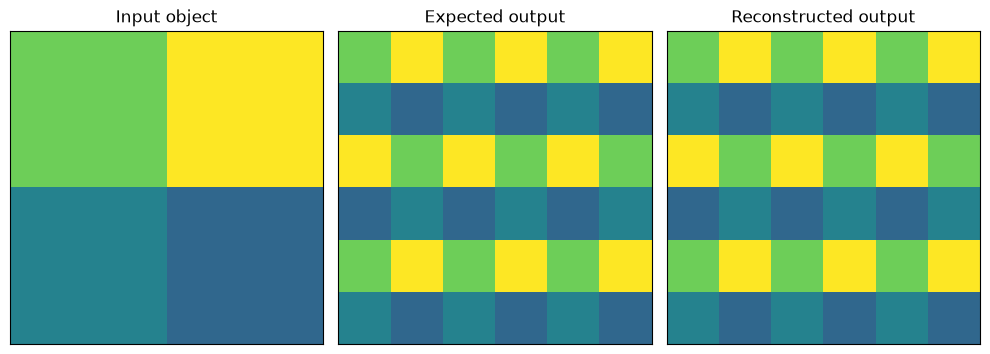

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

axes[0].imshow(input, vmin=0, vmax=9)
axes[0].set_title("Input object")

axes[1].imshow(output, vmin=0, vmax=9)
axes[1].set_title("Expected output")

axes[2].imshow(manual_output, vmin=0, vmax=9)
axes[2].set_title("Reconstructed output")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

In [4]:
cells

,row,column,value,block_row,block_column,block_id,within_block_row,within_block_column,original_value,reflected_value,matches_original,matches_reflected,matches_background
0,0,0,7,0,0,0,0,0,7,9,True,False,False
1,0,1,9,0,0,0,0,1,9,7,True,False,False
2,0,2,7,0,1,1,0,0,7,9,True,False,False
3,0,3,9,0,1,1,0,1,9,7,True,False,False
4,0,4,7,0,2,2,0,0,7,9,True,False,False
5,0,5,9,0,2,2,0,1,9,7,True,False,False
6,1,0,4,0,0,0,1,0,4,3,True,False,False
7,1,1,3,0,0,0,1,1,3,4,True,False,True
8,1,2,4,0,1,1,1,0,4,3,True,False,False
9,1,3,3,0,1,1,1,1,3,4,True,False,True
